# 📈 Financial Market Return & Volatility Forecasting

This project focuses on forecasting stock market returns and volatility using a combination of **statistical models**, **machine learning algorithms**, and **deep learning techniques**.

The objective is to compare the predictive performance of traditional time-series models and modern machine learning approaches in financial markets.

## Models Implemented

• ARIMA – Time Series Forecasting  
• GARCH – Volatility Modeling  
• Random Forest – Machine Learning  
• XGBoost – Gradient Boosting Model  
• LSTM – Deep Learning for Sequential Data

## Technologies Used

Python  
Pandas & NumPy  
Scikit-Learn  
TensorFlow / Keras  
Statsmodels  
Plotly & Matplotlib

## Data Source

Financial data is collected using **Yahoo Finance API** via the `yfinance` library.

---

This project demonstrates how **quantitative finance techniques and data science methods** can be combined to build a financial forecasting system.

#Installing Required Libraries

In this step we install the necessary Python libraries required for financial data analysis, machine learning modeling, and visualization.

In [67]:
!pip install yfinance pmdarima arch xgboost ta tensorflow

# Importing Required Libraries

We import several Python libraries for:

• Data manipulation → Pandas, NumPy  
• Visualization → Matplotlib, Seaborn  
• Time Series Models → ARIMA, GARCH  
• Machine Learning → Random Forest, XGBoost  
• Deep Learning → LSTM (TensorFlow/Keras)

These libraries allow us to build a complete **financial forecasting pipeline**.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

from arch import arch_model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

#  Data Collection

Financial market data is collected using the **Yahoo Finance API**.

The `yfinance` library allows us to download historical stock price data including:

• Open price  
• High price  
• Low price  
• Close price  
• Volume

For this project we analyze historical market data from **2015 to 2025**.

In [69]:
ticker = "^NSEI"

data = yf.download(
    ticker,
    start="2015-01-01"
)

data = data[['Close']]
data.dropna(inplace=True)

data.head()

/tmp/ipykernel_670/3555355373.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,^NSEI
Date,
2015-01-02,8395.450195
2015-01-05,8378.400391
2015-01-06,8127.350098
2015-01-07,8102.100098
2015-01-08,8234.599609


# Exploratory Data Analysis (EDA)

Before building forecasting models, we first explore the data to understand:

• Price trends
• Market volatility
• Seasonal patterns
• Market crashes or sudden changes

Visualization helps reveal important characteristics of financial time series.





# Log Return Calculation

Financial models typically use **logarithmic returns** instead of raw prices.

Log returns are calculated as:

log_return = ln(Pt / Pt-1)

Advantages of log returns:

• They stabilize variance  
• They make the series more stationary  
• They are additive over time  
• Widely used in quantitative finance

In [70]:
data["Returns"] = np.log(data["Close"] / data["Close"].shift(1))
data.dropna(inplace=True)


## Financial Performance Metrics

In this section we compute important financial performance indicators used in quantitative finance.

Metrics analyzed:

• Annualized Volatility  
• Sharpe Ratio  

These metrics help evaluate the risk-return characteristics of the asset.

In [71]:
# Annualized volatility
volatility = data["Returns"].std() * np.sqrt(252)

# Sharpe ratio
risk_free_rate = 0.02
sharpe_ratio = (data["Returns"].mean()*252 - risk_free_rate) / volatility

print("Annualized Volatility:", volatility)
print("Sharpe Ratio:", sharpe_ratio)

Annualized Volatility: 0.1632067533605461
Sharpe Ratio: 0.451742195694671


## Rolling Volatility Analysis

Financial markets often experience periods of high and low volatility.

To visualize volatility clustering we calculate a rolling volatility measure.

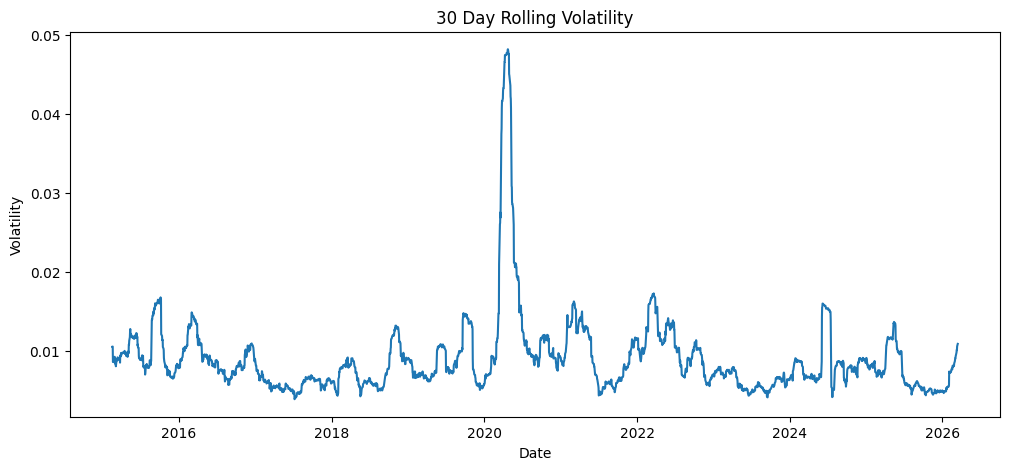

In [72]:
data["Rolling Volatility"] = data["Returns"].rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(data.index, data["Rolling Volatility"])

plt.title("30 Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

# Feature Engineering

Machine learning models require input features.

For time series forecasting we create **lagged features**, which represent previous time steps of the return series.

Examples:

Lag1 → previous day's return  
Lag2 → return two days ago  
Lag3 → return three days ago

These features allow machine learning models to learn temporal dependencies.

In [73]:

data["lag1"] = data["Returns"].shift(1)
data["lag2"] = data["Returns"].shift(2)
data["lag3"] = data["Returns"].shift(3)

data["rolling_vol"] = data["Returns"].rolling(5).std()

data["realized_vol"] = data["Returns"].rolling(5).std()

data.dropna(inplace=True)

## Feature Correlation Analysis

Before training machine learning models we analyze the relationship between features.

This helps understand how lag variables influence returns.

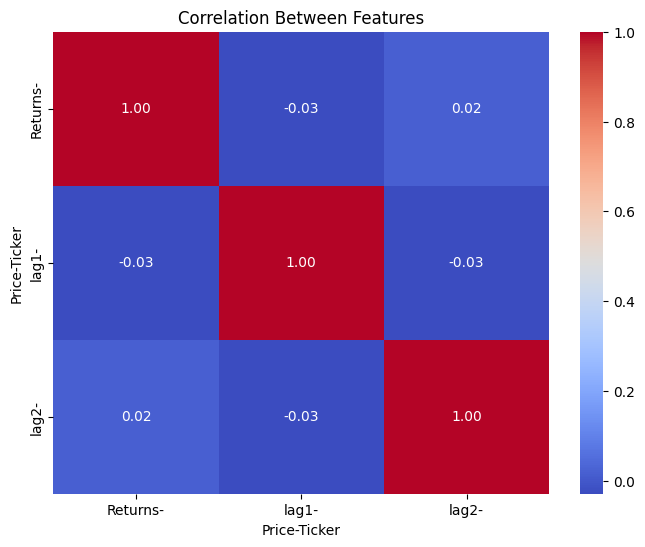

In [74]:
plt.figure(figsize=(8,6))

corr = data[["Returns","lag1","lag2"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Features")

plt.show()

# Train-Test Split

To evaluate the forecasting models properly, we split the dataset into:

Training Data → Used to train the model  
Testing Data → Used to evaluate prediction performance

We use an **80% training and 20% testing split**.

In [75]:
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

features = ["lag1","lag2","lag3","rolling_vol"]

X_train = train[features]
X_test = test[features]

y_train = train["Returns"]
y_test = test["Returns"]

# ARIMA Time Series Model

ARIMA (AutoRegressive Integrated Moving Average) is one of the most widely used statistical models for time-series forecasting.

ARIMA consists of three components:

AR (AutoRegression) → relationship with past values  
I (Integration) → differencing to make the series stationary  
MA (Moving Average) → modeling error terms

In this project we use ARIMA to forecast future stock prices.

In [76]:
auto_model = auto_arima(
    train["Returns"],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal=False,
    trace=True
)

order = auto_model.order

arima = ARIMA(train["Returns"], order=order)

arima_fit = arima.fit()

arima_pred = arima_fit.forecast(steps=len(test))

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-13598.109, Time=0.16 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-13596.824, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-13596.801, Time=0.56 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-13594.812, Time=1.27 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-13599.380, Time=0.57 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-13598.220, Time=0.56 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-13598.195, Time=2.39 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-13596.196, Time=3.86 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 9.536 seconds


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

ARIMA Forecast Plot

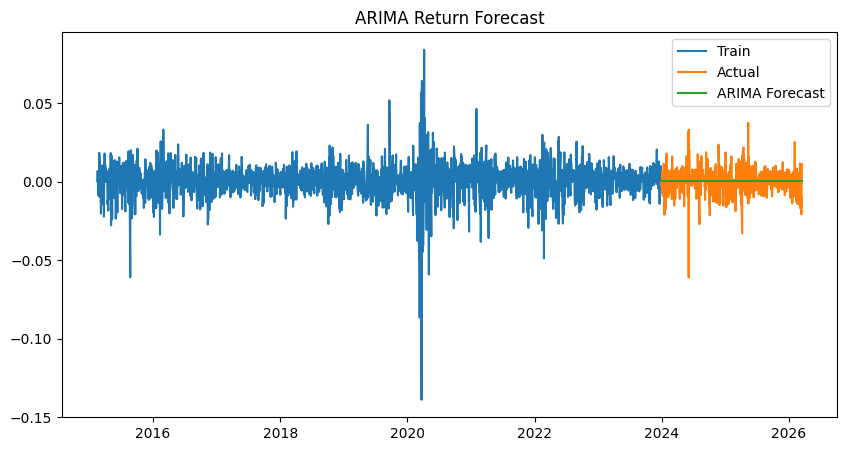

In [77]:
plt.figure(figsize=(10,5))

plt.plot(train.index,train["Returns"],label="Train")

plt.plot(test.index,test["Returns"],label="Actual")

plt.plot(test.index,arima_pred,label="ARIMA Forecast")

plt.legend()
plt.title("ARIMA Return Forecast")

plt.show()

In [78]:

def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"Model: {name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("---------------------")

In [79]:
evaluate_model("ARIMA", test["Returns"], arima_pred)

Model: ARIMA
RMSE: 0.008291188465341735
MAE: 0.00588437526528197
---------------------


In [80]:
arima_results = pd.DataFrame({
    "Actual": test["Returns"].values,
    "ARIMA_Predicted": arima_pred.values
}, index=test.index)

arima_results.head()

,Actual,ARIMA_Predicted
Date,,
2023-12-29,-0.002174,0.00041
2024-01-01,0.000483,0.00041
2024-01-02,-0.003506,0.00041
2024-01-03,-0.006875,0.00041
2024-01-04,0.006543,0.00041


# Volatility Modeling using GARCH

Financial markets exhibit **volatility clustering**, meaning large price movements are often followed by large movements.

To model this behavior we use the **GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model**.

GARCH is widely used in:

• Financial risk management  
• Options pricing  
• Portfolio optimization

In [81]:
garch_predictions_rolling = []

# Initialize history with the 'Returns' series from the training data
history_garch_rolling = train['Returns'].tolist()

for i in range(len(test)):
    # Ensure the model receives a 1-dimensional array of returns
    model_garch_rolling = arch_model(pd.Series(history_garch_rolling), vol='GARCH', p=1, q=1)

    model_fit_garch_rolling = model_garch_rolling.fit(disp='off')

    forecast_garch_rolling = model_fit_garch_rolling.forecast(horizon=1)

    vol_garch_rolling = np.sqrt(forecast_garch_rolling.variance.values[-1,0])

    garch_predictions_rolling.append(vol_garch_rolling)

    # Append only the 'Returns' value from the test set for the next iteration
    history_garch_rolling.append(test['Returns'].iloc[i])

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001148. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001148. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/usr/local/lib/python3.12/dist-packages/arch/univariate/base

In [82]:
realized_vol = test["realized_vol"]

garch_vol_results = pd.DataFrame({
    "Date": realized_vol.index,
    "Realized_Volatility": realized_vol,
    "EGARCH_Predicted": garch_predictions_rolling
})

garch_vol_results.head()

,Date,Realized_Volatility,EGARCH_Predicted
Date,,,
2023-12-29,2023-12-29,0.004337,0.007857
2024-01-01,2024-01-01,0.004683,0.007578
2024-01-02,2024-01-02,0.005617,0.007270
2024-01-03,2024-01-03,0.004717,0.007115
2024-01-04,2024-01-04,0.005030,0.007257


In [83]:
garch_vol = np.array(garch_predictions_rolling)

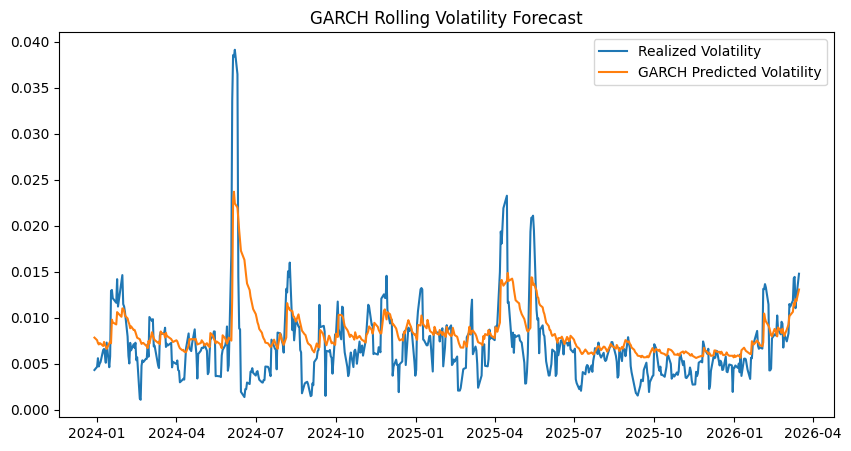

In [84]:
plt.figure(figsize=(10,5))

plt.plot(realized_vol.index, realized_vol,
         label="Realized Volatility")

plt.plot(realized_vol.index, garch_vol,
         label="GARCH Predicted Volatility")

plt.title("GARCH Rolling Volatility Forecast")

plt.legend()

plt.show()

Egarch

In [85]:
egarch_predictions = []

# Initialize history with the 'Returns' series from the training data, scaled by 100
history = (train['Returns']*100).tolist()

for i in range(len(test)):
    # Ensure the model receives a 1-dimensional array of returns
    model = arch_model(pd.Series(history), vol='EGARCH', p=1, q=1)

    model_fit = model.fit(disp='off')

    forecast = model_fit.forecast(horizon=1)

    # Get volatility and divide by 100 to bring it back to original scale
    vol = np.sqrt(forecast.variance.values[-1,0]) / 100

    egarch_predictions.append(vol)

    # Append only the 'Returns' value from the test set for the next iteration, scaled by 100
    history.append(test['Returns'].iloc[i]*100)

In [86]:
egarch_vol_results = pd.DataFrame({
    "Date": realized_vol.index,
    "Realized_Volatility": realized_vol,
    "EGARCH_Predicted": egarch_predictions
})

egarch_vol_results.head()

,Date,Realized_Volatility,EGARCH_Predicted
Date,,,
2023-12-29,2023-12-29,0.004337,0.007756
2024-01-01,2024-01-01,0.004683,0.007476
2024-01-02,2024-01-02,0.005617,0.006959
2024-01-03,2024-01-03,0.004717,0.006889
2024-01-04,2024-01-04,0.005030,0.007184


In [87]:
egarch_vol = np.array(egarch_predictions)

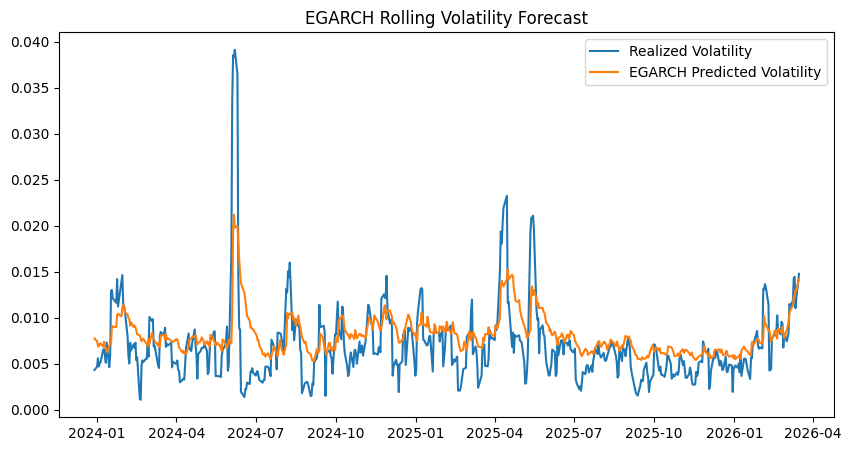

In [88]:
plt.figure(figsize=(10,5))

plt.plot(realized_vol.index, realized_vol,
         label="Realized Volatility")

plt.plot(realized_vol.index, egarch_vol,
         label="EGARCH Predicted Volatility")

plt.title("EGARCH Rolling Volatility Forecast")

plt.legend()

plt.show()

GJR train-test forcast

In [89]:
gjr_predictions = []

# Initialize history with the 'Returns' series from the training data, scaled by 100
history = (train['Returns']*100).tolist()

for i in range(len(test)):
    # Ensure the model receives a 1-dimensional array of returns
    model = arch_model(pd.Series(history), vol='GARCH', p=1, o=1, q=1) # GJR-GARCH is GARCH with 'o' parameter

    model_fit = model.fit(disp='off')

    forecast = model_fit.forecast(horizon=1)

    # Get volatility and divide by 100 to bring it back to original scale
    vol = np.sqrt(forecast.variance.values[-1,0]) / 100

    gjr_predictions.append(vol)

    # Append only the 'Returns' value from the test set for the next iteration, scaled by 100
    history.append(test['Returns'].iloc[i]*100)

In [90]:
gjr_vol_results = pd.DataFrame({
    "Date": realized_vol.index,
    "Realized_Volatility": realized_vol,
    "EGARCH_Predicted": gjr_predictions
})

gjr_vol_results.head()

,Date,Realized_Volatility,EGARCH_Predicted
Date,,,
2023-12-29,2023-12-29,0.004337,0.006765
2024-01-01,2024-01-01,0.004683,0.006668
2024-01-02,2024-01-02,0.005617,0.006496
2024-01-03,2024-01-03,0.004717,0.006534
2024-01-04,2024-01-04,0.005030,0.007012


In [91]:
gjr_vol = np.array(gjr_predictions)

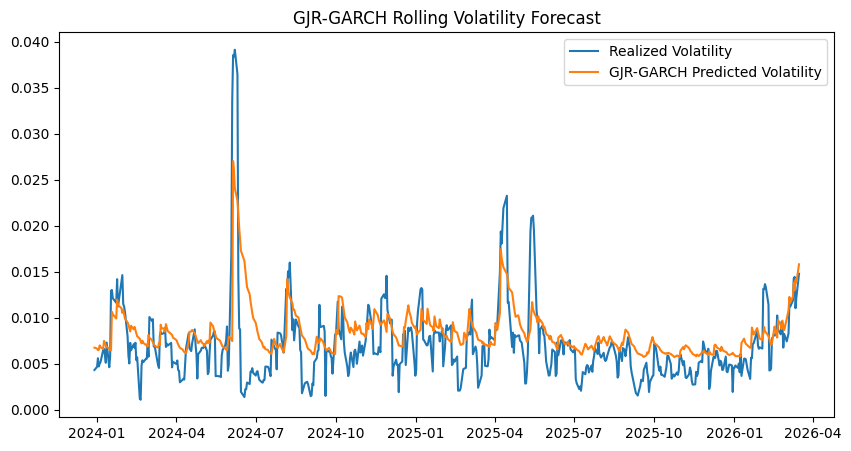

In [92]:
plt.figure(figsize=(10,5))

plt.plot(realized_vol.index, realized_vol,
         label="Realized Volatility")

plt.plot(realized_vol.index, gjr_vol,
         label="GJR-GARCH Predicted Volatility")

plt.title("GJR-GARCH Rolling Volatility Forecast")

plt.legend()

plt.show()

In [93]:
volatility_predictions_comparison = pd.DataFrame({
    "Date": realized_vol.index,
    "Realized_Volatility": realized_vol,
    "GARCH_Predicted": garch_vol,
    "EGARCH_Predicted": egarch_vol,
    "GJR_Predicted": gjr_vol
})

display(volatility_predictions_comparison.head())

,Date,Realized_Volatility,GARCH_Predicted,EGARCH_Predicted,GJR_Predicted
Date,,,,,
2023-12-29,2023-12-29,0.004337,0.007857,0.007756,0.006765
2024-01-01,2024-01-01,0.004683,0.007578,0.007476,0.006668
2024-01-02,2024-01-02,0.005617,0.007270,0.006959,0.006496
2024-01-03,2024-01-03,0.004717,0.007115,0.006889,0.006534
2024-01-04,2024-01-04,0.005030,0.007257,0.007184,0.007012


Garch for Simulation

In [94]:
returns = train["Returns"]*100

garch = arch_model(
    returns,
    vol="GARCH",
    p=1,
    q=1
)

garch_fit = garch.fit()

garch_forecast = garch_fit.forecast(
    horizon=len(test),
     method= 'simulation', # Use simulation for horizon > 1
    simulations=1000 # Number of simulations
)

garch_vol = np.sqrt(
    garch_forecast.variance.values[-1,:]
)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 633423583016.1709
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1207976615.6686902
Iteration:      3,   Func. Count:     23,   Neg. LLF: 2859.0828869567767
Iteration:      4,   Func. Count:     29,   Neg. LLF: 2841.116615494453
Iteration:      5,   Func. Count:     35,   Neg. LLF: 2841.94733988124
Iteration:      6,   Func. Count:     42,   Neg. LLF: 2834.7794768790322
Iteration:      7,   Func. Count:     48,   Neg. LLF: 2834.7718581415347
Iteration:      8,   Func. Count:     53,   Neg. LLF: 2834.771840122333
Iteration:      9,   Func. Count:     57,   Neg. LLF: 2834.771840122386
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2834.771840122333
            Iterations: 9
            Function evaluations: 57
            Gradient evaluations: 9


EGARCH

In [95]:
egarch = arch_model(
    returns,
    vol="EGARCH",
    p=1,
    q=1
)

egarch_fit = egarch.fit()

egarch_forecast = egarch_fit.forecast(
    horizon=len(test),
    method='simulation', # Use simulation for horizon > 1
    simulations=1000 # Number of simulations
)

egarch_vol = np.sqrt(
    egarch_forecast.variance.values[-1,:]
)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1300598128973.317
Iteration:      2,   Func. Count:     15,   Neg. LLF: 16685.830249324063
Iteration:      3,   Func. Count:     24,   Neg. LLF: 20065019.20472821
Iteration:      4,   Func. Count:     33,   Neg. LLF: 2847.7834919796983
Iteration:      5,   Func. Count:     40,   Neg. LLF: 2835.2969624656753
Iteration:      6,   Func. Count:     46,   Neg. LLF: 2835.293030453904
Iteration:      7,   Func. Count:     51,   Neg. LLF: 2835.2930233912084
Iteration:      8,   Func. Count:     56,   Neg. LLF: 2835.293022147706
Iteration:      9,   Func. Count:     60,   Neg. LLF: 2835.2930221474453
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2835.293022147706
            Iterations: 9
            Function evaluations: 60
            Gradient evaluations: 9


GJR-GARCH

In [96]:
gjr = arch_model(
    returns,
    vol="GARCH",
    p=1,
    o=1,
    q=1
)

gjr_fit = gjr.fit()

gjr_forecast = gjr_fit.forecast(
    horizon=len(test),
    method= 'simulation', # Use simulation for horizon > 1
    simulations=1000 # Number of simulations
)

gjr_vol = np.sqrt(
    gjr_forecast.variance.values[-1,:]
)

Iteration:      1,   Func. Count:      7,   Neg. LLF: 12397.44231961032
Iteration:      2,   Func. Count:     18,   Neg. LLF: 1101860.0711724423
Iteration:      3,   Func. Count:     28,   Neg. LLF: 4642.107774152784
Iteration:      4,   Func. Count:     36,   Neg. LLF: 5092.93405594876
Iteration:      5,   Func. Count:     43,   Neg. LLF: 2822.9223908868116
Iteration:      6,   Func. Count:     50,   Neg. LLF: 2794.845581461131
Iteration:      7,   Func. Count:     56,   Neg. LLF: 2794.2706773400614
Iteration:      8,   Func. Count:     62,   Neg. LLF: 2794.2122657534
Iteration:      9,   Func. Count:     68,   Neg. LLF: 2794.2089867355216
Iteration:     10,   Func. Count:     74,   Neg. LLF: 2794.2086185417265
Iteration:     11,   Func. Count:     80,   Neg. LLF: 2794.2086098947257
Iteration:     12,   Func. Count:     85,   Neg. LLF: 2794.208609896771
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2794.2086098947257
            Iterations: 

Volatility Comparison Plot

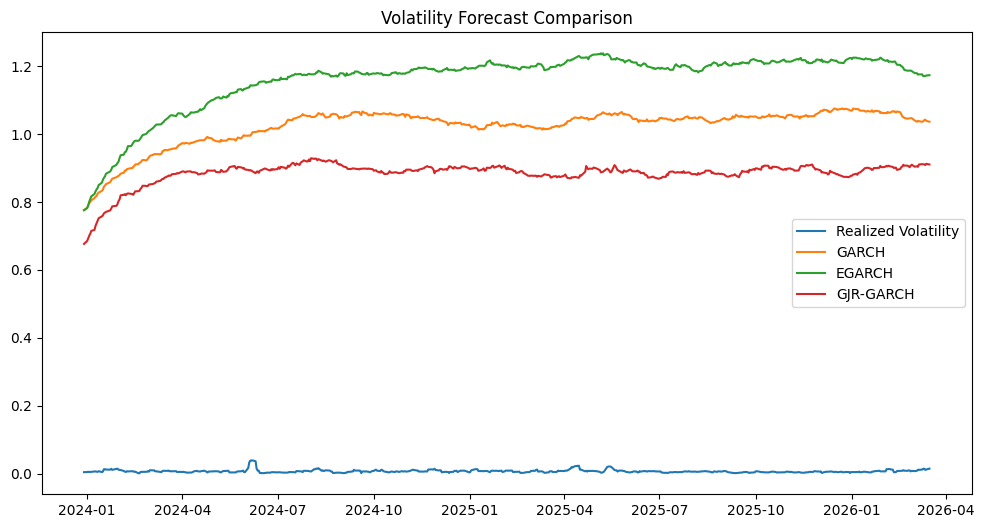

In [97]:
realized_vol = test["realized_vol"]

plt.figure(figsize=(12,6))

plt.plot(test.index,realized_vol,label="Realized Volatility")

plt.plot(test.index,garch_vol,label="GARCH")

plt.plot(test.index,egarch_vol,label="EGARCH")

plt.plot(test.index,gjr_vol,label="GJR-GARCH")

plt.legend()

plt.title("Volatility Forecast Comparison")

plt.show()

In [98]:
volatility_results = pd.DataFrame({

"Model":[
"GARCH",
"EGARCH",
"GJR-GARCH"
],

"AIC":[
garch_fit.aic,
egarch_fit.aic,
gjr_fit.aic
],

"BIC":[
garch_fit.bic,
egarch_fit.bic,
gjr_fit.bic
]

})

volatility_results

,Model,AIC,BIC
0,GARCH,5677.543680,5700.295669
1,EGARCH,5678.586044,5701.338033
2,GJR-GARCH,5598.417220,5626.857206


#  Machine Learning Models

Traditional statistical models sometimes fail to capture complex nonlinear patterns in financial data.

Therefore we apply machine learning models:

Random Forest  
XGBoost

These models can capture nonlinear relationships and interactions between features.

In [99]:
rf_pipeline = Pipeline([
    ("scaler",StandardScaler()),
    ("model",RandomForestRegressor(n_estimators=200))
])

rf_pipeline.fit(X_train,y_train)

rf_pred = rf_pipeline.predict(X_test)

In [100]:
evaluate_model("Random Forest", y_test, rf_pred)

Model: Random Forest
RMSE: 0.009063139423733232
MAE: 0.00616021409312051
---------------------


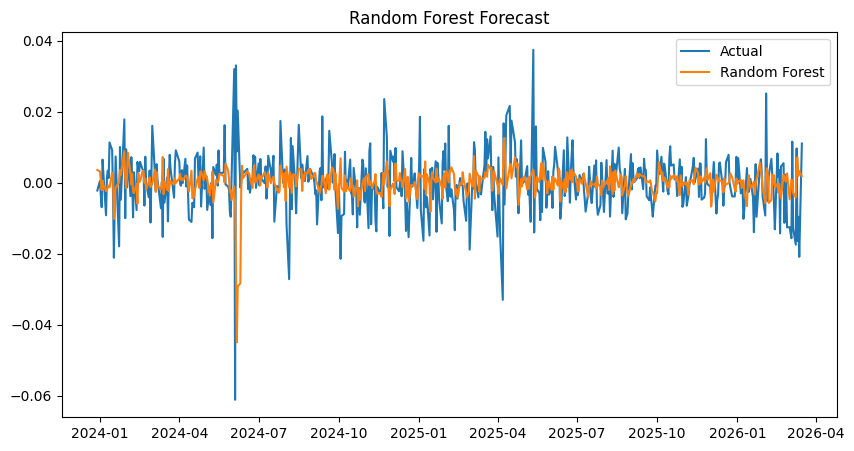

In [101]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(y_test.index, rf_pred, label="Random Forest")

plt.title("Random Forest Forecast")

plt.legend()

plt.show()

In [102]:
rf_results = pd.DataFrame({
    "Date": y_test.index,
    "Actual": y_test,
    "RF_Predicted": rf_pred
})

rf_results.head()

,Date,Actual,RF_Predicted
Date,,,
2023-12-29,2023-12-29,-0.002174,0.003612
2024-01-01,2024-01-01,0.000483,0.003196
2024-01-02,2024-01-02,-0.003506,0.000801
2024-01-03,2024-01-03,-0.006875,-0.002050
2024-01-04,2024-01-04,0.006543,0.000647


XGBoost Model

In [103]:
xgb = XGBRegressor(
    n_estimators=200
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

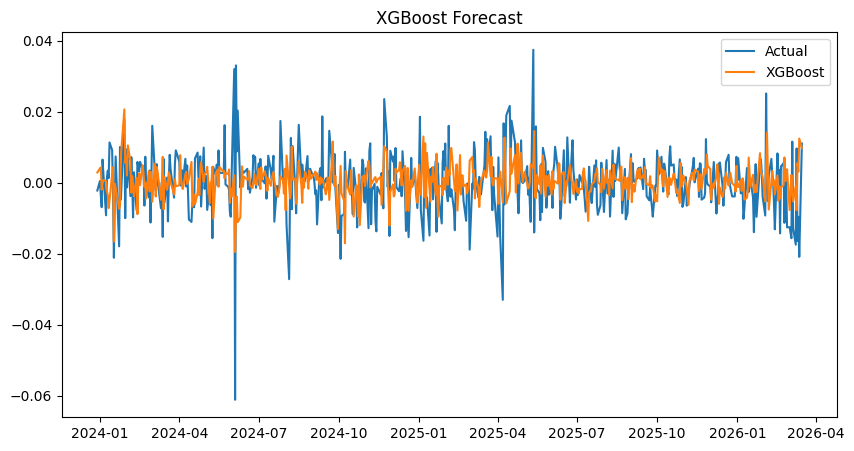

In [104]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual")

plt.plot(y_test.index, xgb_pred, label="XGBoost")

plt.title("XGBoost Forecast")

plt.legend()

plt.show()

In [105]:
evaluate_model("XGBoost", y_test, xgb_pred)

Model: XGBoost
RMSE: 0.009026593557268255
MAE: 0.006607413386910608
---------------------


In [106]:
xgb_results = pd.DataFrame({
    "Date": y_test.index,
    "Actual": y_test,
    "XGB_Predicted": xgb_pred
})

xgb_results.head()

,Date,Actual,XGB_Predicted
Date,,,
2023-12-29,2023-12-29,-0.002174,0.002912
2024-01-01,2024-01-01,0.000483,0.004044
2024-01-02,2024-01-02,-0.003506,0.004314
2024-01-03,2024-01-03,-0.006875,-0.001930
2024-01-04,2024-01-04,0.006543,-0.000146


# LSTM Deep Learning Model

Long Short-Term Memory (LSTM) networks are a type of Recurrent Neural Network (RNN) designed for sequential data.

LSTM models are particularly useful for financial time-series forecasting because they can capture:

• Long-term dependencies
• Temporal patterns
• Nonlinear relationships

In this project we use LSTM to model stock return sequences.

In [107]:
scaler = MinMaxScaler()

scaled_returns = scaler.fit_transform(
    data["Returns"].values.reshape(-1,1)
)

window = 10

X_lstm=[]
y_lstm=[]

for i in range(window,len(scaled_returns)):

    X_lstm.append(scaled_returns[i-window:i,0])
    y_lstm.append(scaled_returns[i,0])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

X_lstm = X_lstm.reshape(
    (X_lstm.shape[0],X_lstm.shape[1],1)
)

In [108]:
split = int(len(scaled_returns)*0.8)

train_lstm = scaled_returns[:split]
test_lstm = scaled_returns[split:]

In [109]:
window = 10

X_train=[]
y_train=[]

for i in range(window,len(train_lstm)):

    X_train.append(train_lstm[i-window:i])
    y_train.append(train_lstm[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [110]:
model = Sequential()

model.add(LSTM(50, return_sequences=False))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0527
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0024
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0024
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0024
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 9/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 10/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024


In [111]:
X_test_lstm = []

for i in range(window,len(test_lstm)):

    X_test_lstm.append(test_lstm[i-window:i])

X_test_lstm = np.array(X_test_lstm)

lstm_pred = model.predict(X_test_lstm)

lstm_pred = scaler.inverse_transform(lstm_pred)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


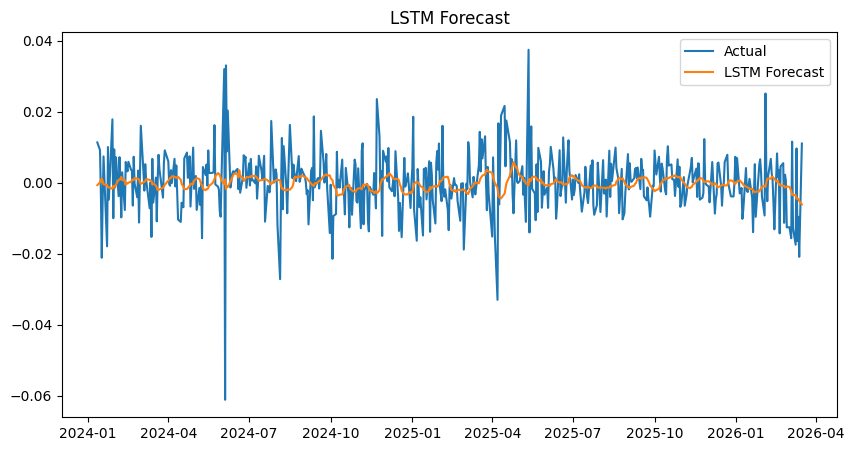

In [112]:
plt.figure(figsize=(10,5))

plt.plot(test.index[-len(lstm_pred):], test["Returns"][-len(lstm_pred):], label="Actual")

plt.plot(test.index[-len(lstm_pred):], lstm_pred, label="LSTM Forecast")

plt.title("LSTM Forecast")

plt.legend()

plt.show()

In [113]:
evaluate_model(
    "LSTM",
    test["Returns"][-len(lstm_pred):],
    lstm_pred.flatten()
)

Model: LSTM
RMSE: 0.0085803466497483
MAE: 0.006147453515313438
---------------------


# Model Evaluation

To compare the performance of different models, we use **Root Mean Squared Error (RMSE)**.

RMSE measures the average prediction error between the predicted and actual values.

Lower RMSE indicates better forecasting performance.

In [114]:
def rmse(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true,y_pred))

def mae(y_true,y_pred):
    return mean_absolute_error(y_true,y_pred)

def mape(y_true,y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true))*100

In [115]:
def directional_accuracy(y_true,y_pred):

    actual_direction = np.sign(y_true.diff().dropna())
    pred_direction = np.sign(pd.Series(y_pred).diff().dropna())

    correct = actual_direction.values == pred_direction.values

    return np.mean(correct)*100

In [116]:
arima_rmse = rmse(test["Returns"],arima_pred)
arima_mae = mae(test["Returns"],arima_pred)
arima_da = directional_accuracy(test["Returns"],arima_pred)


rf_rmse = rmse(y_test,rf_pred)
rf_mae = mae(y_test,rf_pred)
rf_da = directional_accuracy(y_test,rf_pred)


xgb_rmse = rmse(y_test,xgb_pred)
xgb_mae = mae(y_test,xgb_pred)
xgb_da = directional_accuracy(y_test,xgb_pred)


lstm_rmse = rmse(test["Returns"][-len(lstm_pred):],lstm_pred.flatten())
lstm_mae = mae(test["Returns"][-len(lstm_pred):],lstm_pred.flatten())
lstm_da = directional_accuracy(test["Returns"][-len(lstm_pred):],lstm_pred.flatten())

In [117]:
results_table = pd.DataFrame({

"Model":[
"Random Forest",
"XGBoost",
"LSTM"
],

"RMSE":[
rf_rmse,
xgb_rmse,
lstm_rmse
],

"MAE":[
rf_mae,
xgb_mae,
lstm_mae
],

"Directional Accuracy (%)":[
rf_da,
xgb_da,
lstm_da
]

})

results_table

,Model,RMSE,MAE,Directional Accuracy (%)
0,Random Forest,0.009063,0.006160,47.889908
1,XGBoost,0.009027,0.006607,46.605505
2,LSTM,0.008580,0.006147,33.084112


## Model Performance Comparison

We compare the forecasting performance of all models using RMSE.

In [118]:
results = pd.DataFrame({
    "Model": ["Random Forest","XGBoost","LSTM"],
    "RMSE": [rf_rmse, xgb_rmse, lstm_rmse]
})

results.sort_values("RMSE")

,Model,RMSE
2,LSTM,0.008580
1,XGBoost,0.009027
0,Random Forest,0.009063


#  Conclusion

This project demonstrates how different modeling approaches perform in financial market forecasting.

Key Findings:

• Machine learning models capture nonlinear relationships better than classical models.

• ARIMA provides a baseline statistical approach for time-series prediction.

• GARCH successfully models market volatility.

• LSTM networks are capable of learning complex temporal patterns in financial data.

Future Improvements:

• Add Transformer-based models  
• Incorporate macroeconomic indicators  
• Deploy a real-time forecasting dashboard